In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from scipy.stats import linregress


In [6]:
df = pd.read_csv('daily-min-temperatures.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [6]:
# data = {
#     'Month': list(range(1, 13)),
#     'Units': [115, 121, 124, 110, 119, 128, 166, 173, 179, 149, 156, 167]
# }
# df = pd.DataFrame(data)

In [15]:
print(df)

           Date  Temp
0    1981-01-01  20.7
1    1981-01-02  17.9
2    1981-01-03  18.8
3    1981-01-04  14.6
4    1981-01-05  15.8
...         ...   ...
3645 1990-12-27  14.0
3646 1990-12-28  13.6
3647 1990-12-29  13.5
3648 1990-12-30  15.7
3649 1990-12-31  13.0

[3650 rows x 2 columns]


### Plot data

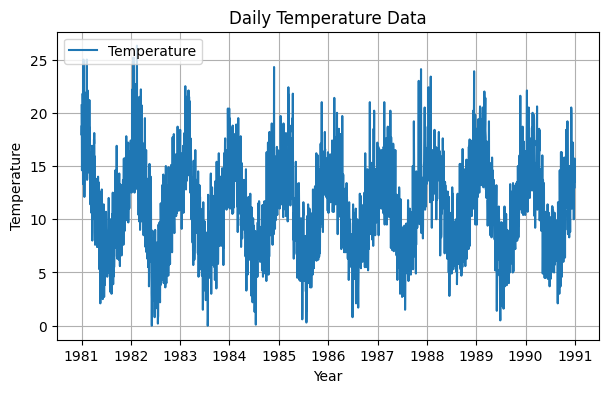

In [44]:
every_nth = 1
df_plot = df.iloc[::every_nth]


plt.figure(figsize=(7, 4))
ax = plt.gca()  # Get the current Axes instance
sns.lineplot(x='Date', y='Temp', data=df_plot)
plt.title('Daily Temperature Data')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.grid(True)
legend_elements = [
    plt.Line2D([0], [0], label='Temperature')
]
plt.legend(handles=legend_elements, loc='upper left')
plt.show()

# Static Method

Mean Squared Error: 2.68


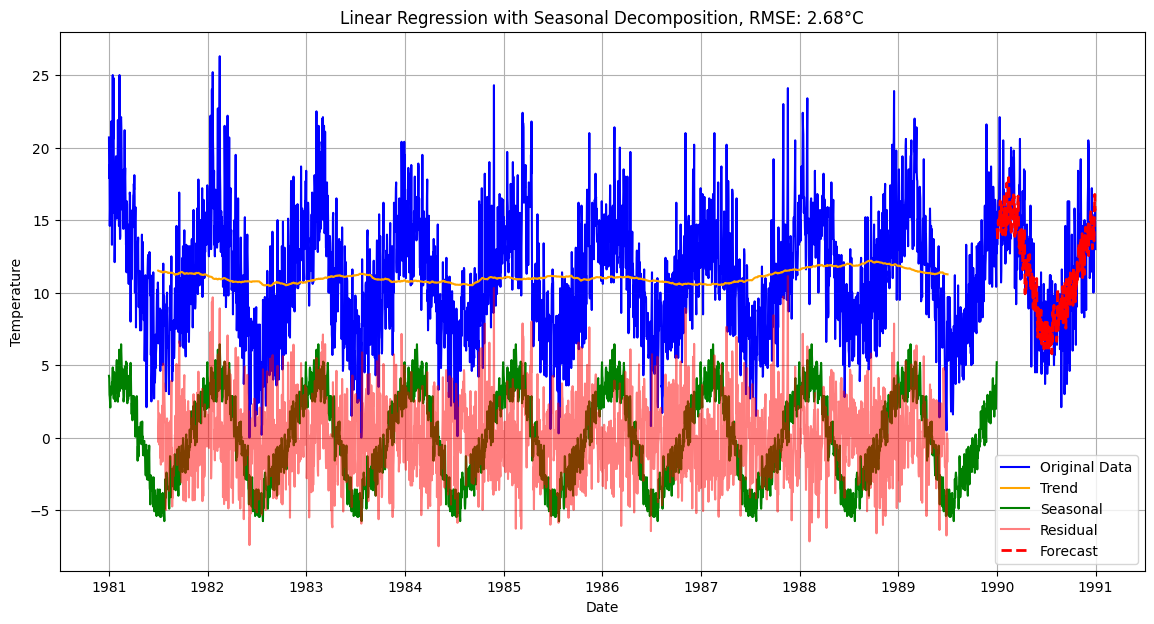

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

period = 365
forecast_days = 365

# make dates numbers, 1,2,3... instead of date objects 
df['Date_ordinal'] = df['Date'].map(pd.Timestamp.toordinal)
first_date_ordinal = df['Date_ordinal'].min()
df['Date_ordinal'] = df['Date_ordinal'] - first_date_ordinal # so it starts from 0 and not 738521


#split data into train and test
df_train = df.iloc[:-forecast_days]
df_test = df.iloc[-forecast_days:]

# use a statsmodels libary to decompose 
result = seasonal_decompose(df_train['Temp'], model='additive', period=period)
trend = result.trend
seasonal = result.seasonal
residual = result.resid


# fit the linear regression on the trend
valid_idx = trend.notna()  # there were nan values that disturbed calculations 
x_valid = df_train.loc[valid_idx, 'Date_ordinal']
y_valid = trend[valid_idx]
slope, intercept, _, _, _ = linregress(x_valid, y_valid)

# forecast the trend
last_ordinal = df_train['Date_ordinal'].max()
future_days = np.arange(last_ordinal + 1, last_ordinal + forecast_days + 1) 
forecast_trend = intercept + slope * future_days # calculates the trend for each of the future days

# find the seasonal pattern for the future days
seasonal_pattern = []
for i in future_days:
    seasonal_index = i % period
    seasonal_value = seasonal[seasonal_index]
    seasonal_pattern.append(seasonal_value)

# final forecast is the sum because the seasonal decomposition is made using addition
y_pred = forecast_trend + seasonal_pattern

#generate future dates for plotting
last_date = df_train['Date'].max()
start_date = last_date + pd.Timedelta(days=1)  #start from the next day
future_dates = pd.date_range(
    start=start_date,      
    periods=forecast_days,  # Number of days to generate
    freq='D'               # Daily
)

#calculate error
mse = mean_squared_error(df_test['Temp'], y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {rmse:.2f}")

# plotting
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Temp'], label='Original Data', color='blue')
plt.plot(df_train['Date'], trend, label='Trend', color='orange')
plt.plot(df_train['Date'], seasonal, label='Seasonal', color='green')
plt.plot(df_train['Date'], residual, label='Residual', color='red', alpha=0.5)
plt.plot(future_dates, y_pred, 'r--', label='Forecast', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Linear Regression with Seasonal Decomposition, RMSE: {:.2f}°C".format(rmse))
plt.legend()
plt.grid(True)
plt.show()







# print("Forecasted Temperatures:")
# for t, pred in zip(df_test['Temp'], y_pred):
#     print(f"True: {t:.2f}, Pred: {pred:.2f}°C")

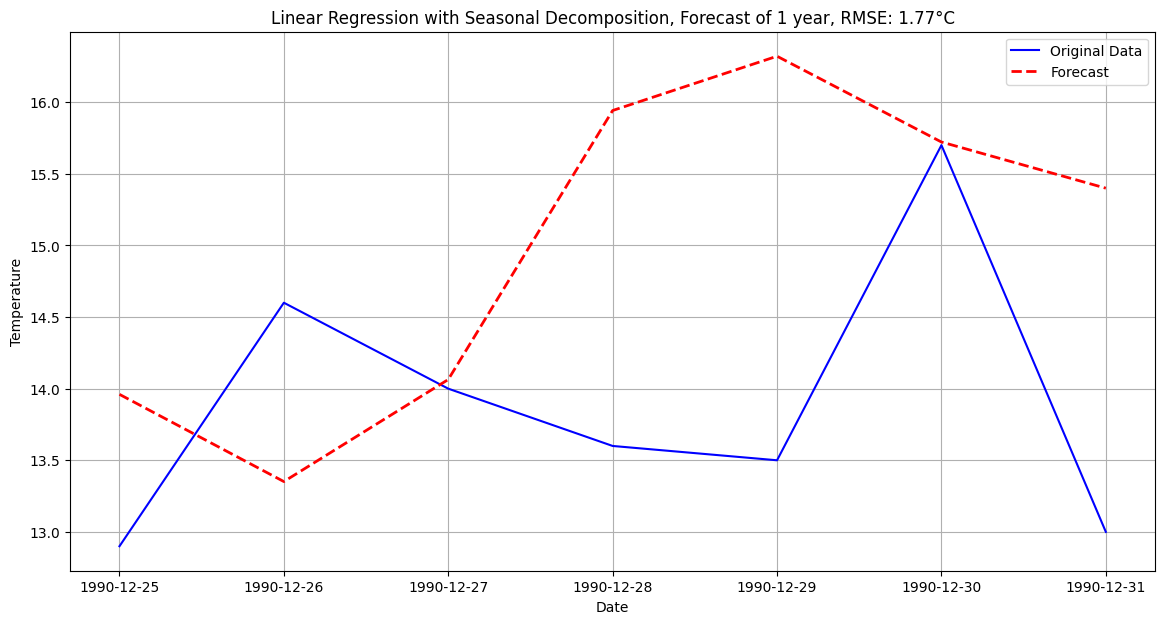

In [87]:
df_last_part = df.iloc[-forecast_days:]

# plotting
plt.figure(figsize=(14, 7))
plt.plot(df_last_part['Date'], df_last_part['Temp'], label='Original Data', color='blue')
plt.plot(future_dates, y_pred, 'r--', label='Forecast', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Linear Regression with Seasonal Decomposition, Forecast of 1 year, RMSE: {:.2f}°C".format(rmse))
plt.legend()
plt.grid(True)
plt.show()


## Using Prophet

21:15:59 - cmdstanpy - INFO - Chain [1] start processing
21:15:59 - cmdstanpy - INFO - Chain [1] done processing


Mean Squared Error: 2.52


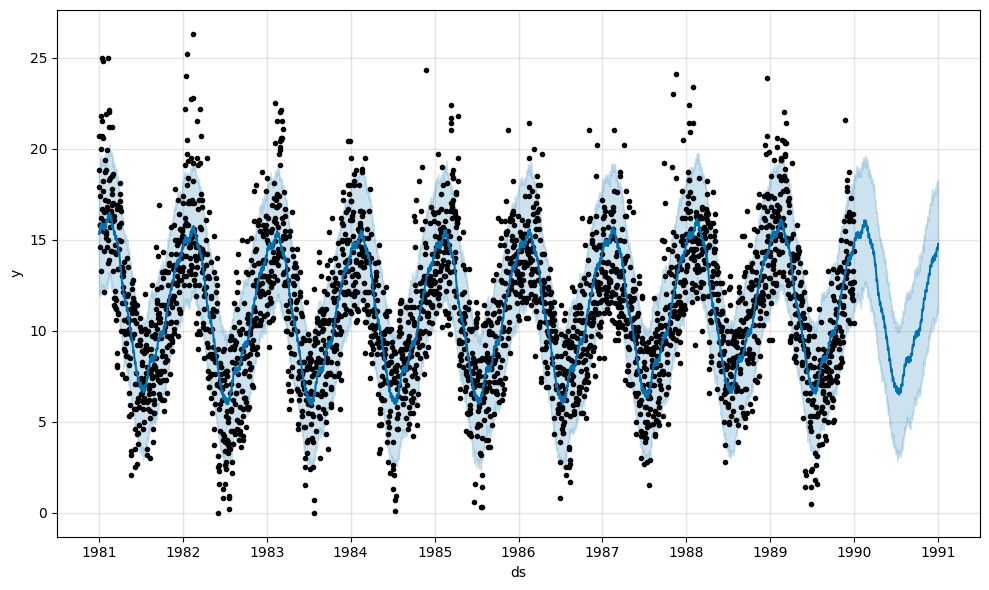

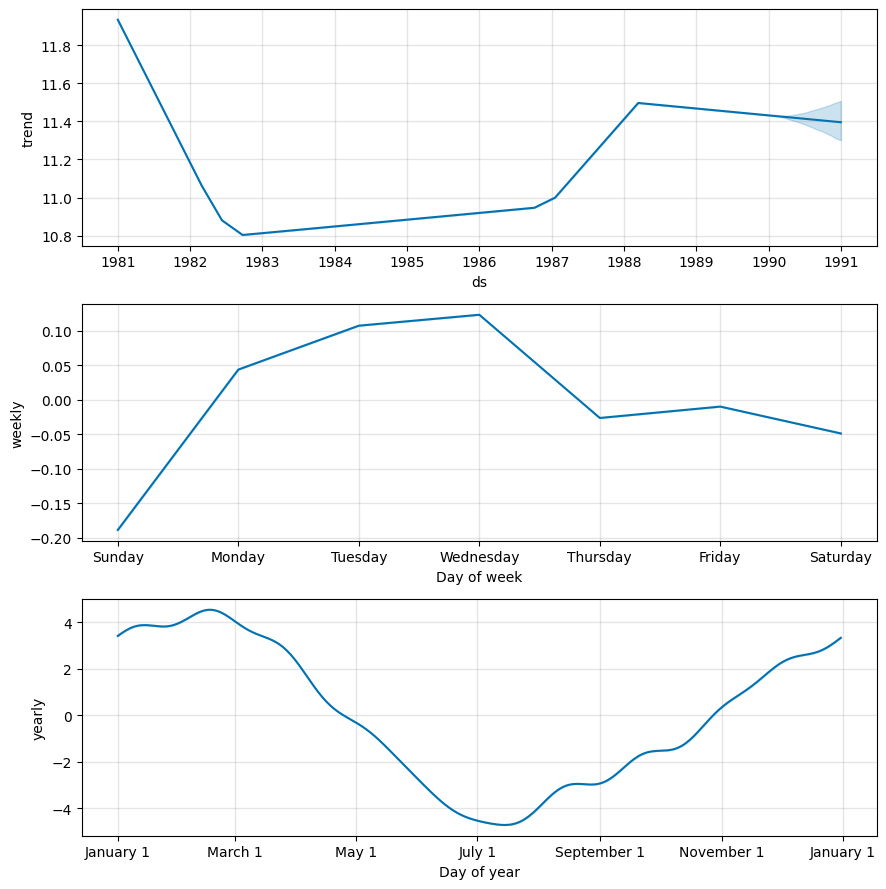

In [103]:
import pandas as pd
from prophet import Prophet

# process data 
p_ds = df.rename(columns={'Date':'ds', 'Temp':'y'})
p_df_train = p_ds.iloc[:-forecast_days]
p_df_test = p_ds.iloc[-forecast_days:]

# create and fit the model
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(p_df_train)

# make predictions
future = m.make_future_dataframe(periods=forecast_days)
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()
y_pred_prophet = forecast['yhat'].iloc[-forecast_days:].values

# calculate error
mse = mean_squared_error(p_df_test['y'], y_pred_prophet)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {rmse:.2f}")


fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

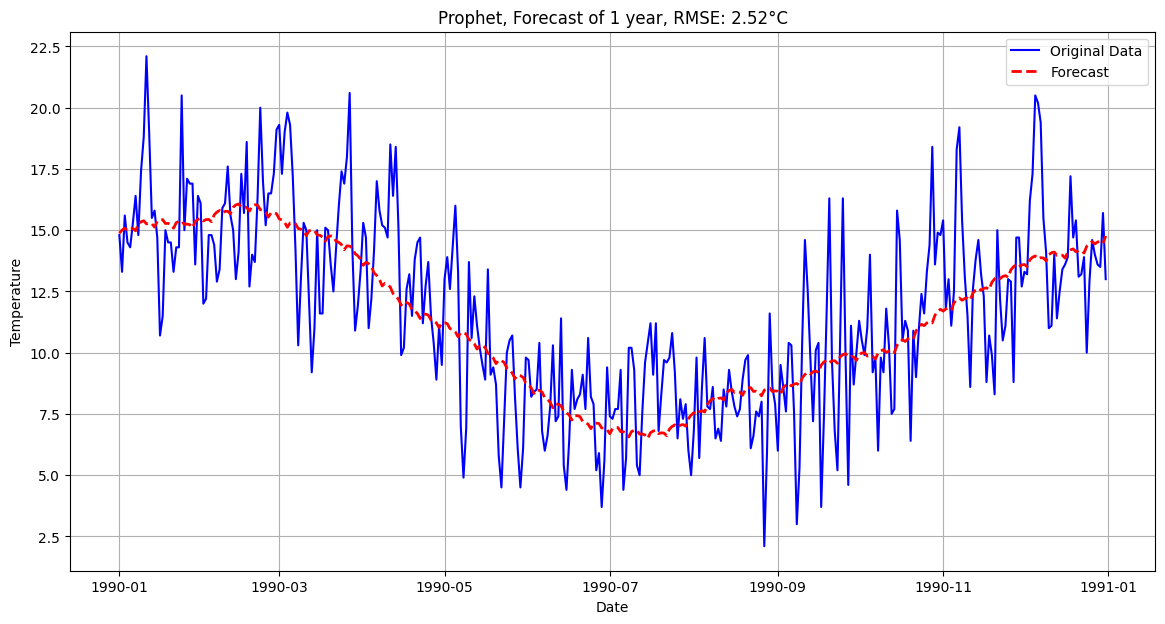

In [104]:
df_last_part = p_ds.iloc[-forecast_days:]

# plotting
plt.figure(figsize=(14, 7))
plt.plot(df_last_part['ds'], df_last_part['y'], label='Original Data', color='blue')
plt.plot(future_dates, y_pred_prophet, 'r--', label='Forecast', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Prophet, Forecast of 1 year, RMSE: {:.2f}°C".format(rmse))
plt.legend()
plt.grid(True)
plt.show()

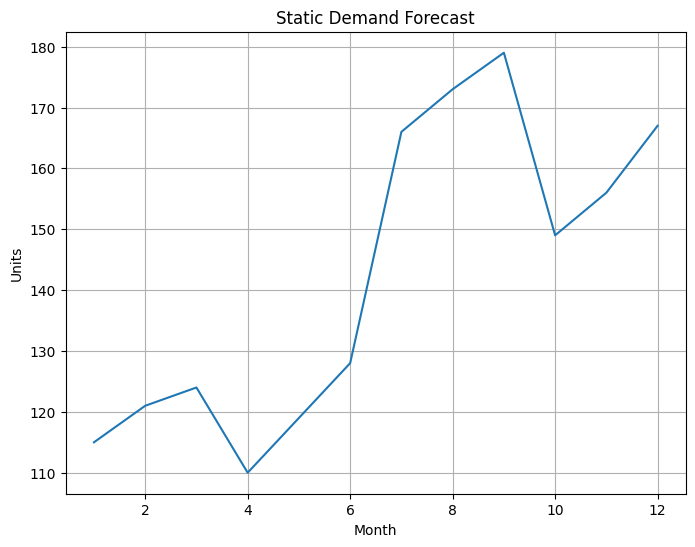

In [4]:
# Plot data
fig = plt.figure(figsize=(8, 6))
ax = fig.subplots()
ax.grid(True)
ax.set_xlabel("Month")
ax.set_ylabel("Units")
ax.set_title("Static Demand Forecast")

ax.plot(df['Month'], df['Units'], label="Units Sold")


In [9]:
    # Remove seasonality
    periodicity = 4  # Periodicity

    if periodicity % 2 != 0:  # Odd kernel
        kernel = np.ones(periodicity) / periodicity
    else:  # Even kernel
        kernel = np.ones(periodicity + 1) / periodicity
        kernel[0] *= 0.5
        kernel[-1] *= 0.5

    # Remove seasonality
    no_seasonality = np.convolve(df['Units'], kernel, mode='valid')
    valid_months = range(1 + periodicity // 2, 1 + len(no_seasonality) + periodicity // 2)  # Valid months without seasonality

    # Add seasonality-removed plot
    ax.plot(valid_months, no_seasonality, label="Units Sold w/o Seasonality")

    # Perform linear regression to find trend (LT)
    T, L, *_ = linregress(valid_months, no_seasonality)

    # Add linear prediction to plot for visualization
    all_months = range(1, 17)
    goal_months = range(13, 17)
    ax.plot(all_months, L + all_months * T, label="Linear Predictions")

    # Find seasonality factors
    linear_past = L + np.array(valid_months) * T
    seasonality_past = df['Units'][:len(linear_past)] / linear_past  # Seasonality factors
    num_full_iterations = len(seasonality_past) // periodicity
    seasonality = np.array([np.mean(seasonality_past[offset::periodicity]) 
                            for offset in range(periodicity)])

    # Estimate future values
    prediction_no_season = L + T * np.array(goal_months)
    seasonality_tiled = np.tile(seasonality, len(goal_months) // len(seasonality) + 1)[:len(goal_months)]
    prediction = prediction_no_season * seasonality_tiled

    # Add prediction to plot
    ax.plot(goal_months, prediction, label="Forecast")

    # Print predictions
    print("Predictions")
    for i, m in enumerate(goal_months):
        print(f"{m}:\t{round(prediction[i])}")

    # Show plot
    ax.legend()
    plt.show()


Predictions
13:	177
14:	184
15:	208
16:	198


# Linear Regression

### Feature Engineering

In [212]:
p = 4 # periodicy 
for i in range(1, p+1):
    df[f'Season_{i}'] = np.where((df['Month'] - 1) % p + 1 == i, 1, 0)
df['Period'] = (df['Month'] - 1) // p + 1
df['Avg_Units_Period'] = df.groupby('Period')['Units'].transform('mean')
df['Season'] = (df['Month'] - 1) % p + 1 
df['Avg_Units_Season'] = df.groupby('Season')['Units'].transform('mean')
df = df.drop(columns=['Season'])

### Fitting Model

In [213]:
X,y = df.drop(['Units'], axis=1), df['Units']

scaler = StandardScaler() # Scaling the data to mean 0, variance 1
X_scaled= scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled,y)

# Display coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_
print("Intercept:", intercept)
print("Coefficients:\n", coefficients)

Intercept: 142.25
Coefficients:
 Month                0.421433
Season_1            -1.067640
Season_2            -2.371704
Season_3             1.579277
Season_4             1.860067
Period              -0.398717
Avg_Units_Period    18.716080
Avg_Units_Season     3.087960
dtype: float64


In [214]:
forecast_months = [13, 14, 15, 16]
forecast_data = pd.DataFrame({'Month': forecast_months})
for i in range(1, p+1):
    forecast_data[f'Season_{i}'] = np.where((forecast_data['Month'] - 1) % p + 1 == i, 1, 0)
forecast_data['Period'] = (df['Month'] - 1) // p + 1
forecast_data['Avg_Units_Period'] = df['Avg_Units_Period']
forecast_data['Avg_Units_Season'] = df['Avg_Units_Season']

### Predicting new months

In [215]:
X = forecast_data
X_scaled = scaler.transform(X)
forecast_data['Forecast'] = model.predict(X_scaled)

In [217]:
forecast_data.rename(columns={'Forecast': 'Units'}, inplace=True)
complete_df = pd.concat([df, forecast_data], ignore_index=True)

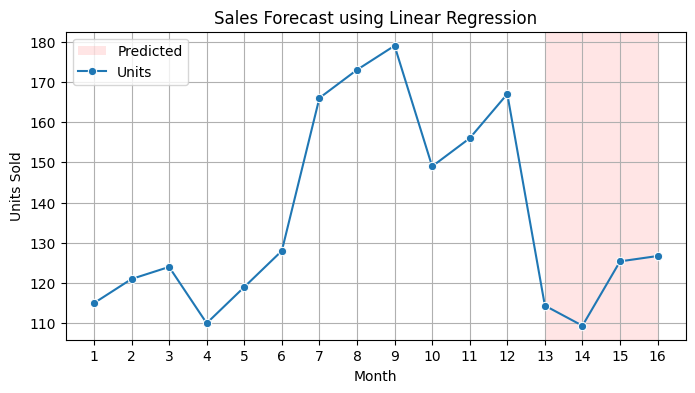

In [183]:
plt.figure(figsize=(8, 4))
ax = plt.gca()  # Get the current Axes instance
ax.axvspan(13, 16, facecolor='red', alpha=0.1, label='Predicted')
sns.lineplot(x='Month', y='Units', data=complete_df, marker='o', label='Units')
plt.title('Sales Forecast using Linear Regression')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(list(range(1, 17)))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
historical_data = {
    'Month': list(range(1, 13)),
    'Units': [115, 121, 124, 110, 119, 128, 166, 173, 179, 149, 156, 167],
    'Type': ['Actual'] * 12  # Labeling these as actual data
}

forecast_data = {
    'Month': [13, 14, 15, 16],
    'Units': [137.67, 132.67, 148.67, 150.00],  # Forecasted values
    'Type': ['Forecast'] * 4  # Labeling these as forecasted data
}
df_historical = pd.DataFrame(historical_data)
df_forecast = pd.DataFrame(forecast_data)
df_manual = pd.concat([df_historical, df_forecast], ignore_index=True)

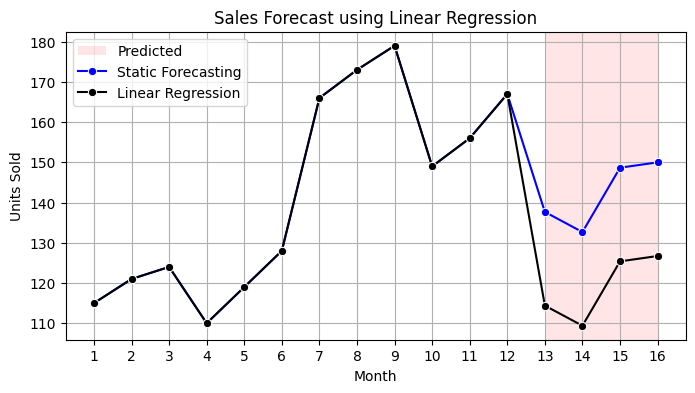

In [202]:
plt.figure(figsize=(8, 4))
ax = plt.gca()  # Get the current Axes instance
ax.axvspan(13, 16, facecolor='red', alpha=0.1, label='Predicted')
sns.lineplot(x='Month', y='Units', data=df_manual, marker='o', label='Static Forecasting', color='blue')
sns.lineplot(x='Month', y='Units', data=complete_df, marker='o', label='Linear Regression', color= 'black')
plt.title('Sales Forecast using Linear Regression')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(list(range(1, 17)))
plt.legend()
plt.grid(True)
plt.show()

# Second Exercise

In [207]:
# Given parameters
alpha = 0.1
beta = 0.2
gamma = 0.3
L0 = 115
T0 = 6.4

m = 12
S = [1.0]*m

Y = [115,121,124,110,119,128,166,173,179,149,156,167]

# Arrays to store the level, trend, and seasonal components
L = [0]*(len(Y)+1)
T = [0]*(len(Y)+1)
L[0] = L0
T[0] = T0


for t in range(1, len(Y)+1):
    # For the first 12 months I use the current seasonal factor since no previous cycle
    season_index = (t-1) % m
    prev_season_index = (t-1 - m) % m if (t-1)>=m else season_index
    
    # Update level
    L[t] = alpha*(Y[t-1]/S[prev_season_index]) + (1-alpha)*(L[t-1]+T[t-1])
    # Update trend
    T[t] = beta*(L[t]-L[t-1]) + (1-beta)*T[t-1]
    # Update seasonal factor
    S[season_index] = gamma*(Y[t-1]/L[t]) + (1-gamma)*S[season_index]

forecast_index = (len(Y)) % m  # month 13's seasonal index corresponds to month 1's seasonal factor
next_month_forecast = (L[len(Y)] + T[len(Y)])*S[forecast_index]
print("Forecast for next month:", next_month_forecast)

Forecast for next month: 177.0820244304613


In summary:

Each month, we first remove last year's seasonality from the observed data to update the level.
Then we calculate how the trend changes based on the new level.
Next, we refine the seasonal factor using the ratio of actual to predicted level.
By the end, we have updated level, trend, and seasonal factors that can be used to predict the next period’s sales.